In [1]:
%pip install monai nibabel torch numpy matplotlib

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.7/2.7 MB 21.5 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.6/16.6 MB 27.9 MB/s  0:00:00 eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.3/3.3 MB 25.3 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 530.7/530.7 MB 5.0 MB/s  0:01:20m0:00:0100:03m
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 366.1/366.1 MB 6.9 MB/s  0:00:58m0:00:0100:02
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 169.9/169.9 MB 6.1 MB/s  0:00:27m0:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 196.5/196.5 MB 6.4 MB/s  0:00:31m0:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.4/60.4 MB 6.8 MB/s  0:00:08m0:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 188.3/188.3 MB 7.0 MB/s  0:00:26m0:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.3/6.3 MB 7.8 MB/s  0:00:00m0:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 423.1/423.1 MB 5.8 MB/s  0:01:10m0:00:0100:02
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.7/

Formato da imagem FLAIR: (240, 240, 155)


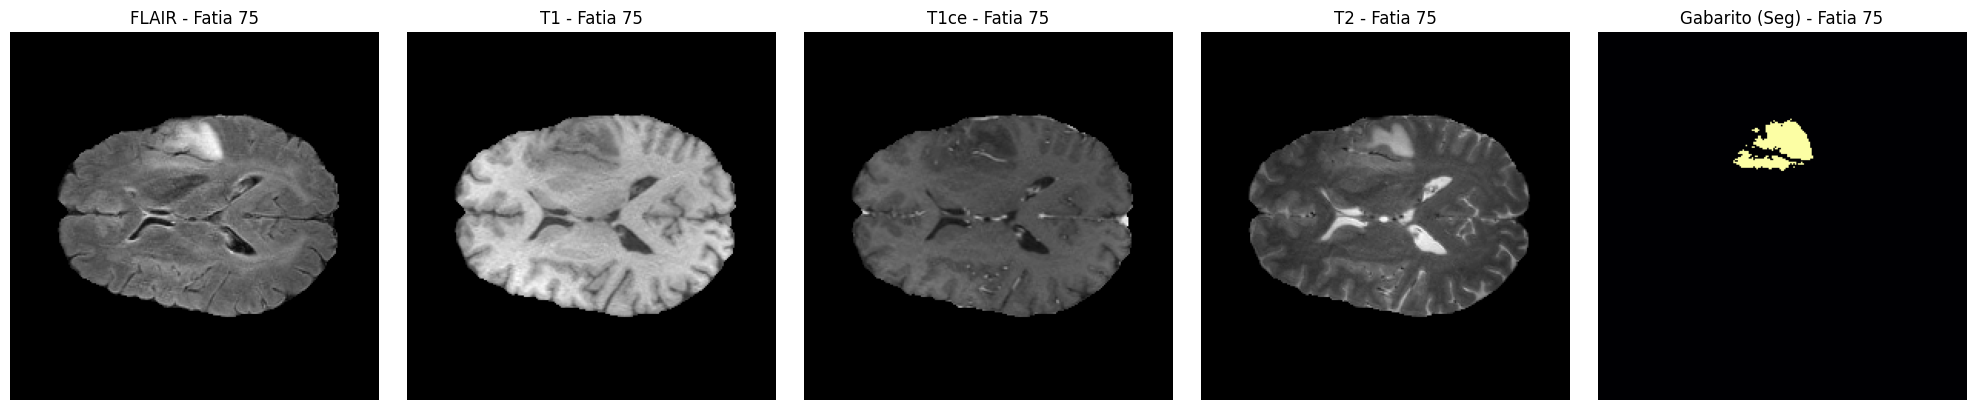

In [4]:
import nibabel as nib
import matplotlib.pyplot as plt

# Caminho base que você mostrou no tree
base_path = "../../data/raw/BraTS2020_TrainingData/MICCAI_BraTS2020_TrainingData/BraTS20_Training_002/"

# 1. Carregando os 5 volumes 3D
flair = nib.load(base_path + "BraTS20_Training_002_flair.nii").get_fdata()
t1    = nib.load(base_path + "BraTS20_Training_002_t1.nii").get_fdata()
t1ce  = nib.load(base_path + "BraTS20_Training_002_t1ce.nii").get_fdata()
t2    = nib.load(base_path + "BraTS20_Training_002_t2.nii").get_fdata()
seg   = nib.load(base_path + "BraTS20_Training_002_seg.nii").get_fdata()

# Imprimindo o formato para confirmar que é 3D
print(f"Formato da imagem FLAIR: {flair.shape}") # Esperado: (240, 240, 155)

# 2. Escolhendo uma fatia do meio (o volume total tem 155 fatias no eixo Z)
fatia = 75

# 3. Plotando tudo lado a lado
fig, axes = plt.subplots(1, 5, figsize=(20, 4))
titulos = ['FLAIR', 'T1', 'T1ce', 'T2', 'Gabarito (Seg)']
volumes = [flair, t1, t1ce, t2, seg]

for i in range(5):
    # Se for o gabarito (seg), usamos um mapa de cores diferente para destacar o tumor
    cmap = 'inferno' if i == 4 else 'gray'
    axes[i].imshow(volumes[i][:, :, fatia], cmap=cmap)
    axes[i].set_title(f'{titulos[i]} - Fatia {fatia}')
    axes[i].axis('off')

plt.tight_layout()
plt.show()